In [1]:
# linear Regression
    # Simple REgression linear (Single feature)
    # Multiple (Multiple features)



In [2]:
import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [3]:
df = pd.DataFrame({
    "Experience" : [1,2,3,4,5],
    "Salary" : [1000, 2000, 3000, 4000, 5000]
})

In [4]:
df

,Experience,Salary
0,1,1000
1,2,2000
2,3,3000
3,4,4000
4,5,5000


Text(0, 0.5, 'Salary')

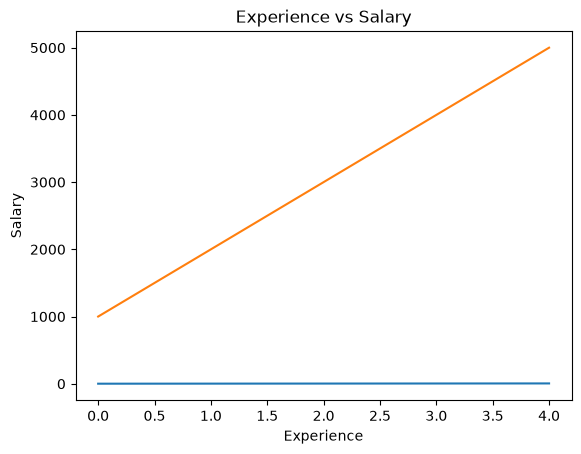

In [5]:
plt.plot(df)
plt.title("Experience vs Salary")
plt.xlabel("Experience")
plt.ylabel("Salary")

In [6]:
# Polynomial regression also uses logistic regression
# y = mx + c

In [31]:
# y = c + mx + m2x^2 +  m3x^3 + m4x^4
polydf = pd.DataFrame({
    "Experience" : [1,2,3,4,5],
    "Salary" : [10000, 15000, 19000, 28000, 30000]
    # "Salary" : [20000, 25000, 32000, 42000, 55000]

})

In [32]:
polydf

,Experience,Salary
0,1,10000
1,2,15000
2,3,19000
3,4,28000
4,5,30000


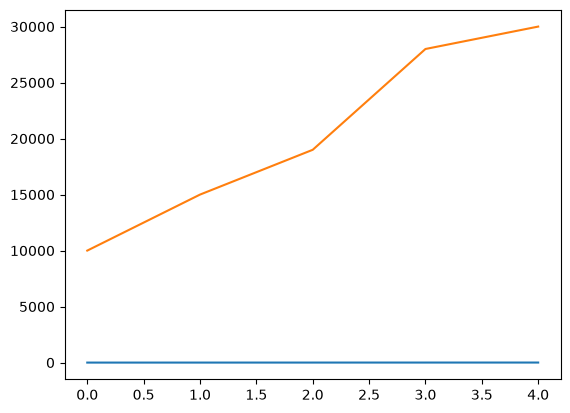

In [33]:
plt.plot(polydf)

In [34]:
X = polydf[["Experience"]]
Y = polydf["Salary"]

linear_model = LinearRegression()
linear_model.fit(X,Y)

l_predict  = linear_model.predict(X)
l_predict

array([ 9800., 15100., 20400., 25700., 31000.])

In [35]:
# here, we got,
    # intercept = c = 480 
    # coefficient = m =  500
    # y = 480 + 500x 


In [36]:
poly = PolynomialFeatures(
    degree =  2,
    include_bias= False
)

In [37]:
poly

,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [38]:
X_poly = poly.fit_transform(X)

X_poly

array([[ 1.,  1.],
       [ 2.,  4.],
       [ 3.,  9.],
       [ 4., 16.],
       [ 5., 25.]])

In [39]:
poly_model = LinearRegression()
poly_model.fit(X_poly,Y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[5728.57, -71.43]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4000
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[19.59, 0.6 ]"


In [40]:
# here we  got,
# y = c + mx + m2x^2

    # y  = 4000 + 5728.57x + (-71.43)x^2

In [41]:
poly_predict = poly_model.predict(X_poly)
poly_predict

array([ 9657.14285714, 15171.42857143, 20542.85714286, 25771.42857143,
       30857.14285714])

In [42]:
comparision  = pd.DataFrame({
    "Experience"  :  polydf["Experience"],
    "Actual Salary" : Y,
    "Linear  Prediction" :  l_predict,
    "Poly  Prediction" :  poly_predict  
})
comparision

,Experience,Actual Salary,Linear Prediction,Poly Prediction
0,1,10000,9800.0,9657.142857
1,2,15000,15100.0,15171.428571
2,3,19000,20400.0,20542.857143
3,4,28000,25700.0,25771.428571
4,5,30000,31000.0,30857.142857


In [43]:
# Residual error is higher in Linear_prediction than Polynomial prediction.


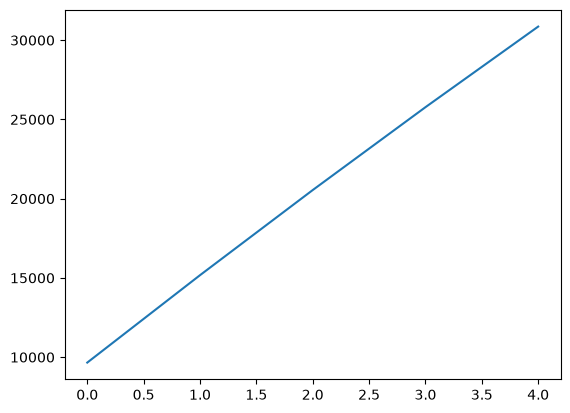

In [45]:
plt.plot(poly_predict)

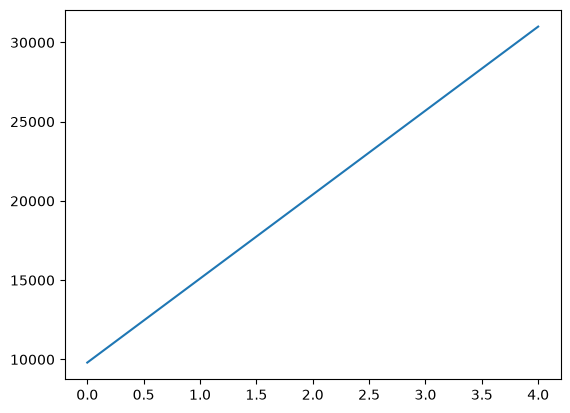

In [46]:
plt.plot(l_predict)

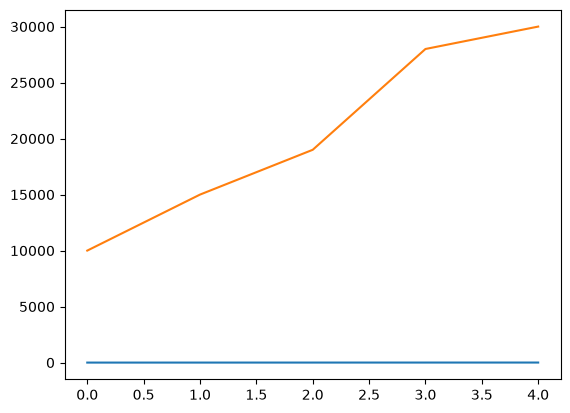

In [47]:
plt.plot(polydf)